## Подготовка

In [1]:
!pip -q install --upgrade nltk matplotlib
!pip -q install --upgrade scikit-learn catboost
!pip -q install wordcloud==1.8.2.2
!pip -q install Pillow==8.4.0
!pip -q install numpy==1.24.4

# Импортируем необходимые библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import time
import nltk

# Загружаем классы для работы с моделями и предварительной обработки данных
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet, stopwords
from sklearn.utils import resample
from nltk.probability import FreqDist
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV, train_test_split

# Загружаем необходимые модели
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier

# Загружаем функции для работы с метриками
from sklearn.metrics import f1_score, roc_auc_score

# Задаем константы
TEST_SIZE = 0.25
RANDOM_STATE = 42

In [2]:
# Считывание данных из csv-файла в датафрейм и сохранение в переменную
df = pd.read_csv('/datasets/toxic_comments.csv')

In [3]:
# Создание функции
def data_info(data):
    '''Функция для вывода общей информации о датасете'''
    print('Первые 5 строк датасета')
    display(data.head())
    print(50*'=')
    print('Количество пропущенных значений:')
    print(data.isna().sum())
    print(50*'=')
    print('Общая информация о датасете')
    data.info()

In [4]:
# Общая информация о датасете df
data_info(df)

Первые 5 строк датасета


,Unnamed: 0,text,toxic
0,0,Explanation\nWhy the edits made under my usern...,0
1,1,D'aww! He matches this background colour I'm s...,0
2,2,"Hey man, I'm really not trying to edit war. It...",0
3,3,"""\nMore\nI can't make any real suggestions on ...",0
4,4,"You, sir, are my hero. Any chance you remember...",0


Количество пропущенных значений:
Unnamed: 0    0
text          0
toxic         0
dtype: int64
Общая информация о датасете
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159292 entries, 0 to 159291
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  159292 non-null  int64 
 1   text        159292 non-null  object
 2   toxic       159292 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 3.6+ MB


Пропущенные значения отсутствуют, типы данных верные.

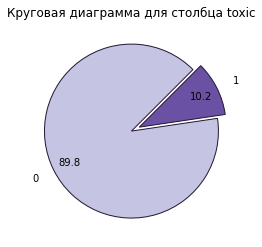

In [5]:
# Построение круговой диаграммы для целевого признака
df['toxic'].value_counts().plot(kind='pie',
                                 autopct='%.1f',
                                 figsize=(4,4),
                                 colors=['#c5c5e3','#6a51a3'],
                                 startangle=45,
                                 wedgeprops={'edgecolor': '#241836', 'linewidth': 1},
                                 labeldistance=1.2,
                                 pctdistance=0.8,
                                 explode=(0, 0.1))
plt.ylabel(' ')
plt.title(f'Круговая диаграмма для столбца toxic')
plt.show()

Позитивных комментариев гораздо больше, чем негативных. В данных наблюдается дисбаланс.

In [6]:
# Загрузка стоп-слов
nltk.download('stopwords', quiet=True)
english_stopwords = stopwords.words('english')
stop_words = list(set(english_stopwords))

In [7]:
# Загрузка необходимых данных
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

True

In [8]:
# Инициализация WordNetLemmatizer()
lemmatizer = WordNetLemmatizer()

def clear_lemm_text(text):
    '''Функция для удаления лишних символов и стоп-слов и лемматизации текста'''
    # Удаление лишних символов
    clear_text = re.sub(r"[^a-zA-Z\s']", ' ', text) 
    clear_text = " ".join(clear_text.split()).lower()
    
    # Удаление стоп-слов
    words = [word for word in clear_text.split(" ") if word and word not in stop_words]
    pos_tags = nltk.pos_tag(words)
    
    # Создание списка
    lemma_words = []
    
    # Лемматизация с учетом части речи
    for word, tag in pos_tags:
        tag = tag[0].upper()
        pos = {'J': wordnet.ADJ,
               'N': wordnet.NOUN,
               'V': wordnet.VERB,
               'R': wordnet.ADV}

        lemma = lemmatizer.lemmatize(word, pos.get(tag, wordnet.NOUN))
        lemma_words.append(lemma)
    
     # Объединение текста
    lemma_text = " ".join(lemma_words)
    
    return lemma_text, lemma_words

In [9]:
# Применение функции и сохранение результата в списки
lemma_data = df['text'].apply(clear_lemm_text).tolist()

In [10]:
# Разделение результата на столбец и общий список со словами
df['lemma_text'] = [item[0] for item in lemma_data]
all_lemma_words = [word for item in lemma_data for word in item[1]]

In [11]:
# Первые 5 строк датасета
df.sample(10)

,Unnamed: 0,text,toxic,lemma_text
138184,138335,"""\nActually, I believe he was saying fixed bec...",0,actually believe say fix problem way afd templ...
104231,104328,Congressional district images \n\nI suggest le...,0,congressional district image suggest leave ima...
96712,96805,"""\n\nI just cleared another one of your ill-in...",0,clear another one ill inform edits dharmic rel...
28968,29005,I guess that's an improvement. It would help i...,0,guess that's improvement would help indicate r...
115620,115719,Why is there so much written about the one Wor...,0,much write one world championship play compare...
36700,36742,It’s interesting to see who is a supporter of ...,0,interest see supporter anjem choudary wikipedia
111927,112024,"""\n\nAgree with Shahid, you do not need to doc...",0,agree shahid need document every single minor ...
83765,83844,"""\n\nKen Catchpole\nA """"{{prod}}"""" template ha...",0,ken catchpole prod template add article ken ca...
56189,56250,"""\nI think the he was ruled out for there prev...",0,think rule previous match know would ok play o...
99419,99515,do explain \n\nHow to upload an image. The ent...,0,explain upload image entire procedure clumsy p...


In [12]:
# Подсчёт распределения частот слов в тексте
fdist = FreqDist(all_lemma_words)
# Получение частовстречающихся слов
fdist.most_common(5)

[('article', 72651),
 ('page', 56848),
 ('wikipedia', 45821),
 ('talk', 40252),
 ('use', 32324)]

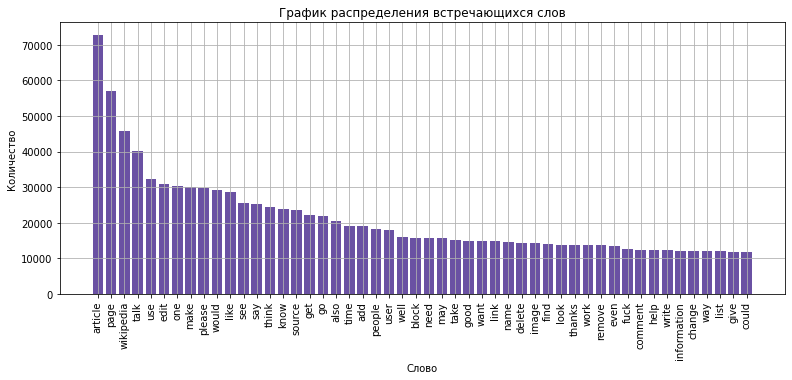

In [13]:
# Получение данных для построения графика 
words, frequencies = zip(*fdist.most_common(50))

# Построение графика распределения
plt.figure(figsize=(13, 5))
plt.bar(words, frequencies, color='#6a51a3')
plt.title('График распределения встречающихся слов')
plt.ylabel('Количество')
plt.xlabel('Слово')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

In [14]:
# Объединение в одну строку всех слов
all_lemma_words = ' '.join(all_lemma_words)

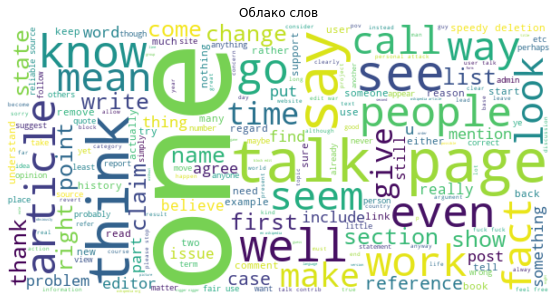

In [15]:
# Создание и отображение облака слов
wordcloud = WordCloud(background_color='white', 
                      width=600, 
                      height=300, 
                      max_words=200, 
                      stopwords=None, 
                      colormap='viridis').generate(all_lemma_words)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Облако слов')
plt.show()

In [16]:
# Создание корпуса
corpus = list(df['lemma_text'].values)
corpus[0]

'explanation edits make username hardcore metallica fan revert vandalisms closure gas vote new york doll fac please remove template talk page since retire'

In [17]:
# Добавление результатов в датасет
df_corpus = pd.DataFrame(corpus)
df['corpus'] = df_corpus
df.head()

,Unnamed: 0,text,toxic,lemma_text,corpus
0,0,Explanation\nWhy the edits made under my usern...,0,explanation edits make username hardcore metal...,explanation edits make username hardcore metal...
1,1,D'aww! He matches this background colour I'm s...,0,d'aww match background colour seemingly stuck ...,d'aww match background colour seemingly stuck ...
2,2,"Hey man, I'm really not trying to edit war. It...",0,hey man really try edit war guy constantly rem...,hey man really try edit war guy constantly rem...
3,3,"""\nMore\nI can't make any real suggestions on ...",0,can't make real suggestion improvement wonder ...,can't make real suggestion improvement wonder ...
4,4,"You, sir, are my hero. Any chance you remember...",0,sir hero chance remember page that's,sir hero chance remember page that's


In [18]:
# Отбор 50000 случайных строк для уменьшения датасета
df_small = resample(df, n_samples=50000, random_state=RANDOM_STATE)
df_small.shape

(50000, 5)

In [19]:
# Выделение входных признаков
X = df_small['corpus']
# Целевой признак
y = df_small['toxic']
# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = TEST_SIZE,
                                                    random_state = RANDOM_STATE,
                                                    stratify = y)
# Проверка размерности тренировочных и тестовых выборок
print(X_train.shape)
X_test.shape

(37500,)


(12500,)

In [20]:
# Векторизация данных
count_tf_idf = TfidfVectorizer(stop_words=stop_words, max_features=50000, sublinear_tf=True, ngram_range=(1, 2), min_df=5)
X_train_tf_idf = count_tf_idf.fit_transform(X_train)
X_test_tf_idf = count_tf_idf.transform(X_test)

In [21]:
# Проверка размерности тренировочных и тестовых выборок после векторизации
print(X_train_tf_idf.shape)
X_test_tf_idf.shape

(37500, 37087)


(12500, 37087)

**Вывод**

Из общей информации видно, что в данных нет проблем. Столбец с комментариями был лемманизирован и очищен от лишних символов. Из датасета были выделены входные и целевой признак, разделены на тренировочную и тестовую выборки и векторизированы.

## Обучение

In [22]:
# Создание словаря моделей и их гиперпараметров
models = {
    'LogisticRegression': {
        'model': LogisticRegression(class_weight='balanced',
                                    random_state=RANDOM_STATE,
                                    solver='liblinear',
                                    n_jobs=-1),
        'params': {
            'penalty': ['l1', 'l2'], 
            'C': [0.1, 1, 10]},
        'fit_params': {}
    },
    
    'CatBoost': {
        'model': CatBoostClassifier(loss_function='Logloss', 
                                    eval_metric='F1',
                                    random_state=RANDOM_STATE, 
                                    verbose=False, 
                                    thread_count=-1),
        'params': {
            'iterations': [100, 200],
            'depth': list(range(3, 6)),
            'learning_rate': [0.01, 0.1],
            'scale_pos_weight': [1, 5, 10]},
        'fit_params': {
            'early_stopping_rounds': 10,
            'cat_features': None}
    },
    
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', 
                                        random_state=RANDOM_STATE, 
                                        n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]},
        'fit_params': {}
    }
}

In [23]:
# Создание пустого списка для заполнения результатами расчетов
results = []

def model_fit(model, param, fit_params, model_name):
    '''Функция для подбора гиперпараметров для модели и ее обучения'''
    # Подбор гиперпараметров для модели
    randomized_search = RandomizedSearchCV(
        model, 
        param, 
        cv=3,
        scoring=['f1', 'roc_auc'],
        refit = 'f1',
        random_state=RANDOM_STATE,
        n_jobs=-1, 
        error_score='raise', 
        verbose=1, 
        n_iter=3)
    
    # Обучение модель
    randomized_search.fit(X_train_tf_idf, y_train, **fit_params)
    
    
    # Определение лучших параметров и лучшей метрики модели
    best_params = randomized_search.best_params_ 
    f1_rs = randomized_search.best_score_ # метрика F1 лучшей модели
    best_index = randomized_search.best_index_ # индекс лучшей модели
    time_fit = randomized_search.cv_results_['mean_fit_time'][best_index] # время обучения лучшей модели
    time_predict = randomized_search.cv_results_['mean_score_time'][best_index] # время предсказаний лучшей модели
    roc_auc_rs = randomized_search.cv_results_['mean_test_roc_auc'][best_index] # метрика ROC-AUC лучшей модели
    
    # Вывод информации
    print(f'Время обучения модели: {round(time_fit,3)} секунд')
    print(f'Лучшие параметры: {best_params}')
    print(f'Время выполнения предсказаний модели: {round(time_predict,3)} секунд')
    print(f'Лучшая метрика F1: {round(f1_rs, 3)}')  
    print(f'Наилучшее значение ROC-AUC: {round(roc_auc_rs, 3)}')
    
    return (best_params, f1_rs, roc_auc_rs, time_fit, time_predict)

In [24]:
def model_result(model_name, model_data):
    '''Функция для определения гиперпараметров модели'''
    print(f'\n=== {model_name} ===')

    # Определение параметров функции model_fit()
    best_params, f1_rs, roc_auc_rs, time_fit, time_predict = model_fit(
        model_data['model'], 
        model_data['params'], 
        model_data['fit_params'], 
        model_name)
    
    # Сохранение результатов в список
    results.append({
        'model_name': model_name,
        'best_params': best_params,
        'time_fit': time_fit,
        'time_predict': time_predict,
        'f1_rs': round(f1_rs,2), 
        'roc_auc_rs': round(roc_auc_rs,2),})
    
    return results

In [25]:
# Определение лучшей модели логической регресии
# И определение время исполнения кода в ячейке
start_time_total = time.time()

# Вызов функции model_result()
model_result('LogisticRegression', models['LogisticRegression'])

end_time_total = time.time()
total_time = round(end_time_total - start_time_total, 2)
print(f'\nОбщее время выполнения кода в ячейке: {round(total_time / 60, 2)} минут')


=== LogisticRegression ===
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Время обучения модели: 3.974 секунд
Лучшие параметры: {'penalty': 'l2', 'C': 10}
Время выполнения предсказаний модели: 0.192 секунд
Лучшая метрика F1: 0.781
Наилучшее значение ROC-AUC: 0.964

Общее время выполнения кода в ячейке: 0.42 минут


In [26]:
# Определение лучшей модели градиентного бустинга
# И определение время исполнения кода в ячейке
start_time_total = time.time()

# Вызов функции model_result()
model_result('CatBoost', models['CatBoost'])

end_time_total = time.time()
total_time = round(end_time_total - start_time_total, 2)
print(f'\nОбщее время выполнения кода в ячейке: {round(total_time / 60, 2)} минут')


=== CatBoost ===
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Время обучения модели: 89.534 секунд
Лучшие параметры: {'scale_pos_weight': 10, 'learning_rate': 0.1, 'iterations': 200, 'depth': 5}
Время выполнения предсказаний модели: 0.227 секунд
Лучшая метрика F1: 0.699
Наилучшее значение ROC-AUC: 0.943

Общее время выполнения кода в ячейке: 10.52 минут


In [27]:
# Определение лучшей модели случайного леса
# И определение время исполнения кода в ячейке
start_time_total = time.time()

# Вызов функции model_result()
model_result('RandomForest', models['RandomForest'])

end_time_total = time.time()
total_time = round(end_time_total - start_time_total, 2)
print(f'\nОбщее время выполнения кода в ячейке: {round(total_time / 60, 2)} минут')


=== RandomForest ===
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Время обучения модели: 26.583 секунд
Лучшие параметры: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Время выполнения предсказаний модели: 1.512 секунд
Лучшая метрика F1: 0.684
Наилучшее значение ROC-AUC: 0.955

Общее время выполнения кода в ячейке: 7.81 минут


In [28]:
# Создание датафрейма из данных в results
results_df = pd.DataFrame(results)
# Установка опции для отображения максимальной ширины столбца
pd.set_option('display.max_colwidth', None)
results_df

,model_name,best_params,time_fit,time_predict,f1_rs,roc_auc_rs
0,LogisticRegression,"{'penalty': 'l2', 'C': 10}",3.973982,0.191502,0.78,0.96
1,CatBoost,"{'scale_pos_weight': 10, 'learning_rate': 0.1, 'iterations': 200, 'depth': 5}",89.534193,0.226932,0.70,0.94
2,RandomForest,"{'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}",26.582671,1.511667,0.68,0.95


По результатам расчетов лучшей моделью является:

LogisticRegression(class_weight='balanced', penalty='l2', C=10, random_state=RANDOM_STATE, solver='liblinear', n_jobs=-1).

In [29]:
# Определение модели
model_lr = LogisticRegression(class_weight='balanced', 
                              solver='liblinear', 
                              random_state=RANDOM_STATE,
                              n_jobs=-1, 
                              penalty='l2', 
                              C=10)

# Обучение модели на тренировочных данных
model_lr.fit(X_train_tf_idf, y_train)

# Предсказание значений на тестовой выборке
y_pred = model_lr.predict(X_test_tf_idf)

# Расчет метрики F1
f1 = f1_score(y_test, y_pred)

print(f'Лучшая метрика F1 на тестовой выборке: {f1:.2f}')

Лучшая метрика F1 на тестовой выборке: 0.79


**Вывод** 

Определена лучшая модель с гиперпараметрами: 

LogisticRegression(class_weight='balanced', penalty='l2', C=10, random_state=RANDOM_STATE, solver='liblinear', n_jobs=-1).

Метрика качества F1 на тестовой выборке составляет 0.79, что выше доспутимого значения 0.75.

## Выводы

**Итоговый вывод**

Разработана модель классификации комментариев на позитивные и негативные в интернет-магазине «Викишоп».

Для этого выполнены следующие шаги:
1. Лемманизирован и очищен от лишних символов текст комментариев. 
2. Выделены входные и целевой признаки, данные разделены на тренировочную и тестовую выборки и векторизированы.
3. Определена лучшая модель с гиперпараметрами: LogisticRegression(class_weight='balanced', penalty='l2', C=10, random_state=RANDOM_STATE, solver='liblinear', n_jobs=-1).
4. Проверено качество модели на тестовой выборке. Метрика качества F1 на тестовой выборке составляет 0.79, что выше допустимого значения 0.75.